# Assignment 2 - Feature extraction and classification

Note: This notebook file for the assignment has deviations from the course guide with respect to the structure, sentence framing, question framing and numbering. Please consider this notebook file structure as the final structure and follow this.

In this assignment, you are expected to

(1) extract global features from CIFAR10 dataset with one of the pre-trained neural networks available in pytorch,

(2) classify the dataset using the traditional k-Nearest Neighbours classifier,

and

(3) implement k-fold cross-validation to evaluate your model.

In [1]:
# Load all the needed packages for this assignment here
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# Additional Libraries
import pandas as pd
from torch.utils.data import random_split, Subset
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import KFold
import torch.nn as nn
from torchvision import models
from sklearn.decomposition import PCA


When working with Pytorch, dataloader() is a must to know function. Read more about this function and the parameters it accepts in https://blog.paperspace.com/dataloaders-abstractions-pytorch/

In [2]:
from torch.utils.data import DataLoader

The variable 'transform' encapsulates the needed transformations of our data. Read more about transforms in https://blog.paperspace.com/dataloaders-abstractions-pytorch/

In [3]:
transform = transforms.Compose([
    # resize
    transforms.Resize(32),
    # center-crop
    transforms.CenterCrop(32),
    # to-tensor
    transforms.ToTensor(),
    # normalize
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

### INPUT DATASET

Load the CIFAR10 dataset from Pytorch

In [4]:
dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)

dataloader = torch.utils.data.DataLoader(
        dataset, 
        batch_size = 4, 
        shuffle = False, # shuffling the data
        num_workers = 0, # allowing multiprocessing 
        collate_fn = None # merging datasets
        )

test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
print(dataset)
print(test_dataset)

Files already downloaded and verified
Files already downloaded and verified
Dataset CIFAR10
    Number of datapoints: 50000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: Compose(
               Resize(size=32, interpolation=bilinear, max_size=None, antialias=True)
               CenterCrop(size=(32, 32))
               ToTensor()
               Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
           )
Dataset CIFAR10
    Number of datapoints: 10000
    Root location: ./data
    Split: Test
    StandardTransform
Transform: Compose(
               Resize(size=32, interpolation=bilinear, max_size=None, antialias=True)
               CenterCrop(size=(32, 32))
               ToTensor()
               Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
           )


In [5]:
# CPU or GPU
device = "cuda" if torch.cuda.is_available() else "cpu"
kwargs = {'num_workers': 1, 'pin_memory': True} if device == 'cuda' else {} 

print(device)

cpu


#### Exercise 2.1 - Dataset preparation

**a)** Write a function **'train_test_split(dataset, ratio)'** which takes a dataset array as an input and returns two dataset arrays- one for training and another for testing.


In [6]:
def train_test_split(feature, labels, ratio):
    size_data = len(feature)
    indices = np.random.permutation(size_data)
    
    train_size = int(size_data * ratio)
    train_idx = indices[:train_size]
    test_idx = indices[train_size:]
    
    x_train = feature[train_idx]
    y_train = labels[train_idx]
    
    x_test = feature[test_idx]
    y_test = labels[test_idx]
        
    return x_train, y_train, x_test, y_test


### FEATURE EXTRACTION

Extract descriptros from the images in your train and test dataset. The dataset split should remain the same for all the experiments if you want to be fair when comparing performance.

#### Exercise 2.2 - Feature 1 - RGB descriptor

Implement the same code you wrote for extracting the overall RGB descriptors(of size n x 24) as in assignment 1 here.

In [7]:
def rgb_descriptor(data):
    
    img = np.array(data)   # shape: (32, 32, 3)

    # per-channel histograms
    r_hist, _ = np.histogram(img[:, :, 0], bins=8, range=(0, 255))
    g_hist, _ = np.histogram(img[:, :, 1], bins=8, range=(0, 255))
    b_hist, _ = np.histogram(img[:, :, 2], bins=8, range=(0, 255))

    # normalize to sum=1 for comparability (optional but recommended)
    r_hist = r_hist / img[:, :, 0].size
    g_hist = g_hist / img[:, :, 1].size
    b_hist = b_hist / img[:, :, 2].size

    # concatenate to 24-D feature
    return np.concatenate([r_hist, g_hist, b_hist])  # shape = (24,)


In [8]:
rgb_descriptors = []
rgb_labels = []

for img, label in dataset:
    rgb_descriptors.append(rgb_descriptor(img))
    rgb_labels.append(label)

rgb_descriptors = np.array(rgb_descriptors)   # shape: (n, 24)
rgb_labels = np.array(rgb_labels)

print(rgb_descriptors.shape)   # (50000, 24)

(50000, 24)


#### Exercise 2.3 - Feature 2 - Extract CNN descriptors using pre-traind networks

Load one of the pretrained network (resnet, alexnet, vgg, squeezenet, densenet, inception) from pytorch to extract global features from the images present in the dataset. 
We will use the output values from the layer present just before the fully connected layer of the deep network as a descriptor, i.e. we will remove the last fully-connected layer. Therefore, after feed-forwarding the input image through the network, we save the output as the descriptor of the image. We do this for all the images present in the dataset to get the overall CNN descriptors.

You may refer to this link for debugging purposes - https://stackoverflow.com/questions/52548174/how-to-remove-the-last-fc-layer-from-a-resnet-model-in-pytorch

In [9]:
# name of the model you wish to use - it should be selected from this list
# [resnet, alexnet, vgg, squeezenet, densenet, inception]
all_models = [m for m  in dir(models)]
#print(all_models)

model = models.resnet18(weights=True)
#print(model)

# removing the final fc-layer and avgpool
model.fc = nn.Identity()
model.to(device).eval

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


<bound method Module.eval of ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      

In [10]:
cnn_descriptors = []
cnn_labels = []

with torch.no_grad():
    for images, labels in dataloader:
        images = images.to(device)
        
        # Forward until the last conv block (512D output)
        features = model(images)         # shape: (B, 512)

        cnn_descriptors.append(features.cpu())
        cnn_labels.append(labels)

# Concatenate everything
cnn_descriptors = torch.cat(cnn_descriptors, dim=0)
cnn_labels = torch.cat(cnn_labels, dim=0)

print("Descriptor tensor shape:", cnn_descriptors.shape)

Descriptor tensor shape: torch.Size([50000, 512])



### PERFORMANCE EVALUATION

#### Exercise 2.4 - Error function

Implement a function to evaluate the accuracy of your prediction. We will rely on the evaluation metric 'accuracy'.

You are suggested to also use f-score, recall and precision. Have a look at https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_recall_fscore_support.html 

In [11]:
def accuracy_metric(actual, predicted):
    
    accuracy_value = accuracy_score(actual, predicted)
    precision, recall, f1, _ = precision_recall_fscore_support(actual, predicted, average = None) # multilabel classification
    
    return {"accuracy": accuracy_value, 
            "precision": precision, 
            "recall": recall, 
            "f1": f1}

### TRAIN AND TEST YOUR MODEL

#### Exercise 2.5 - k Nearest Neighbour model

For this exercise, first split the extracted overall RGB and CNN descriptor to train and test sets with the help of the 'train_test_split()' function that you implemented before.

**a)** Apply the classifier with different values of k (number of nearest neighbours) to the train **RGB descriptor** set and evaluate the performance of your models using the accuracy_metric() function that you implemented before.

You can have a look at the documentation to understand the parameters that define the learning of the model,
https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html#sklearn.neighbors.KNeighborsClassifier


In [21]:
# Splitting the dataset
x_train_rgb,y_train_rgb, x_test_rgb, y_test_rgb = train_test_split(rgb_descriptors,rgb_labels, 0.8)

# Use your k-NN - play with the value of the parameters to see how the model performs
kvalue_list = [2,4,6,10,15] 
results_rgb = {}

for k in kvalue_list:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(x_train_rgb, y_train_rgb)
    y_pred_rgb = knn.predict(x_test_rgb)
    metrics_rgb = accuracy_metric(y_test_rgb, y_pred_rgb)
    results_rgb[k] = metrics_rgb
    print("Metrics for K", k)
    print("Accuracy :", metrics_rgb["accuracy"])
    print("Precision:", metrics_rgb["precision"])
    print("Recall   :", metrics_rgb["recall"])
    print("F1-Score :", metrics_rgb["f1"])
    print("------------------------------")




Metrics for K 2
Accuracy : 0.1365
Precision: [0.17239661 0.14168766 0.10742496 0.13884007 0.11411411 0.11294416
 0.12993421 0.13407821 0.11504425 0.17391304]
Recall   : [0.35706914 0.22410359 0.136      0.22788462 0.11377246 0.08734053
 0.08085977 0.07114625 0.03919598 0.02851324]
F1-Score : [0.23252688 0.17361111 0.1200353  0.17255187 0.11394303 0.09850581
 0.09968454 0.0929632  0.05847076 0.04899388]
------------------------------
Metrics for K 4
Accuracy : 0.1412
Precision: [0.16169355 0.13686026 0.10456274 0.09768638 0.11747851 0.17909091
 0.16161616 0.12922465 0.14412811 0.13827993]
Recall   : [0.41382869 0.23705179 0.11       0.07307692 0.08183633 0.19332679
 0.08188332 0.06422925 0.08140704 0.08350305]
F1-Score : [0.23253117 0.17353263 0.10721248 0.08360836 0.09647059 0.18593676
 0.10869565 0.08580858 0.10404624 0.10412698]
------------------------------
Metrics for K 6
Accuracy : 0.1471
Precision: [0.17393435 0.14017341 0.09793254 0.12172775 0.12887237 0.18109611
 0.15288612 0.

**b)** Apply the classifier with different values of k (number of nearest neighbours) to the train **CNN descriptor** and evaluate the performance of your models using the accuracy_metric() function that you implemented before.

In [20]:
# Ex.2.5b your code here
x_train_cnn,y_train_cnn, x_test_cnn, y_test_cnn = train_test_split(cnn_descriptors,cnn_labels, 0.8)

# Use your k-NN - play with the value of the parameters to see how the model performs
kvalue_list = [2,4,6,10,15] 
results_cnn = {}

for k in kvalue_list:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(x_train_cnn, y_train_cnn)
    y_pred_cnn = knn.predict(x_test_cnn)
    metrics_cnn = accuracy_metric(y_test_cnn, y_pred_cnn)
    results_cnn[k] = metrics_cnn
    print("Metrics for K", k)
    print("Accuracy :", metrics_cnn["accuracy"])
    print("Precision:", metrics_cnn["precision"])
    print("Recall   :", metrics_cnn["recall"])
    print("F1-Score :", metrics_cnn["f1"])
    print("------------------------------")


Metrics for K 2
Accuracy : 0.188
Precision: [0.19626594 0.21759891 0.16009019 0.16755793 0.16681377 0.15384615
 0.23266564 0.1475     0.27669903 0.25342466]
Recall   : [0.41602317 0.32060302 0.28832487 0.18485742 0.18881119 0.11428571
 0.15828092 0.05847374 0.10898662 0.03656126]
F1-Score : [0.26670792 0.25924421 0.20587169 0.17578308 0.17713215 0.13114754
 0.18839676 0.08374734 0.1563786  0.06390328]
------------------------------
Metrics for K 4
Accuracy : 0.2104
Precision: [0.18329466 0.23304473 0.16479895 0.19502618 0.19509476 0.2095672
 0.29342105 0.18790497 0.28085106 0.27536232]
Recall   : [0.45752896 0.32462312 0.25380711 0.14650934 0.17482517 0.0973545
 0.23375262 0.08622398 0.18929254 0.13142292]
F1-Score : [0.26173385 0.27131457 0.19984013 0.16732173 0.18440464 0.13294798
 0.26021004 0.11820652 0.22615648 0.17792642]
------------------------------
Metrics for K 6
Accuracy : 0.2237
Precision: [0.20349104 0.26797945 0.17031802 0.20515971 0.20019724 0.21391304
 0.29157667 0.193

#### Exercise 2.6 - Visualize results 

**a)** Since you already applied PCA to the extracted overall RGB descriptor in assignment 1, now apply PCA to the extracted overall **CNN descriptor**.

Steps to follow:

1) Choose the kNN classifier with k value that gave you the best results in the previous exercise and use it to make predictions on your train CNN descriptor set.

2) Apply PCA on the train set and select the first 2 principal components to represent each sample.

2) Plot the principal components representing the samples with empty circles. Use one color per ground truth class lables. On top of this, plot the samples again but now with filled circles. For these filled circles, use the color of the class predicted per sample in step 1. You can note that misclassifications will make the colours not coincide.

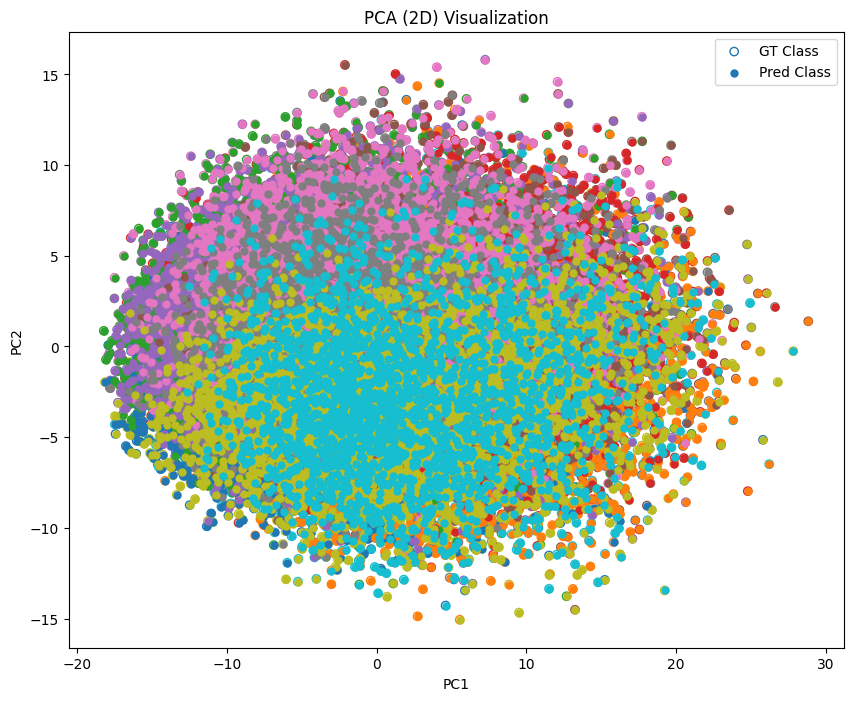

In [28]:
# Ex.2.6a your code here
k = 15
classes = 10
colors = plt.cm.tab10(np.linspace(0, 1, classes))

knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(x_train_cnn, y_train_cnn)
train_pred= knn.predict(x_train_cnn)

pca = PCA(n_components=2)
train_cnn__2d = pca.fit_transform(x_train_cnn)

plt.figure(figsize=(10,8))

for cls in range(classes):
    idx = (y_train_cnn == cls)
    plt.scatter(train_cnn__2d[idx, 0], train_cnn__2d[idx,1], edgecolor=colors[cls], facecolor= 'none', marker = 'o', label=f"GT Class " if cls == 0 else None)
    
for cls in range(classes):
    idx = (train_pred == cls)
    plt.scatter(train_cnn__2d[idx, 0], train_cnn__2d[idx,1], color=colors[cls],  marker = 'o', s=25, label=f"Pred Class" if cls == 0 else None)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA (2D) Visualization")
plt.legend()
plt.show()

**b)** Repeat the steps mentioned before but now on the test CNN descriptor set. 

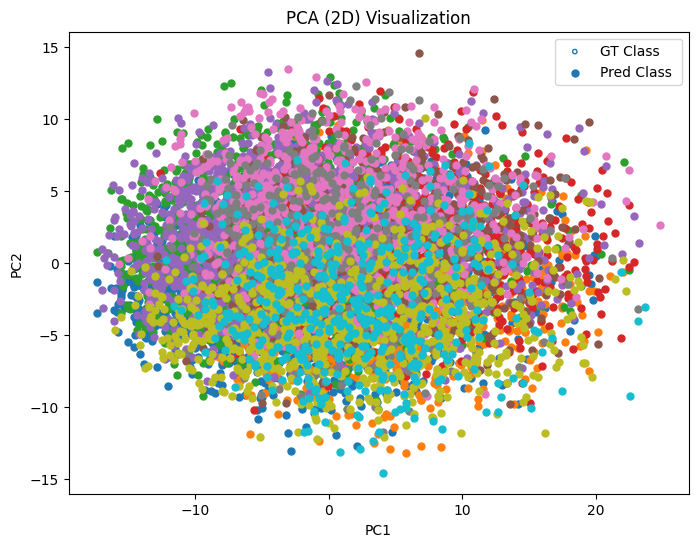

In [29]:
# Ex.2.6b your code here
k = 15
classes = 10
colors = plt.cm.tab10(np.linspace(0, 1, classes))

knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(x_test_cnn, y_test_cnn)
test_pred= knn.predict(x_test_cnn)

pca = PCA(n_components=2)
test_cnn__2d = pca.fit_transform(x_test_cnn)

plt.figure(figsize=(8,6))

for cls in range(classes):
    idx = (y_test_cnn == cls)
    plt.scatter(test_cnn__2d[idx, 0], test_cnn__2d[idx,1], edgecolor=colors[cls], facecolor= 'none', marker = 'o', s=10, label=f"GT Class" if cls == 0 else None)
    
for cls in range(classes):
    idx = (test_pred == cls)
    plt.scatter(test_cnn__2d[idx, 0], test_cnn__2d[idx,1], color=colors[cls],  marker = 'o', s=25, label=f"Pred Class " if cls == 0 else None)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA (2D) Visualization")
plt.legend()
plt.show()

#### Exercise 2.7 - kNN with k-Fold cross-validation

Assess the performance of your implemented kNN using k-Fold cross-validation. 

Run your implemented function evaluating for k (fold) = 2, 5 and 10. You can rely on the kNN that performed best in the previous exercises.
Report the average accuracy and the standard deviation.

In [30]:
# Load packages
from sklearn.model_selection import KFold
import numpy as np
from sklearn.utils import shuffle

# Ex.2.7 your code here
def knn_kfold_eval(features, labels, k_best, n_fold):
    
    kf = KFold(n_splits=n_fold, random_state=None, shuffle=True)
    accuracies= []
    
    for train_idx, test_idx in kf.split(features):
        X_train, X_test = features[train_idx], features[test_idx]
        y_train, y_test = labels[train_idx], labels[test_idx]

        knn = KNeighborsClassifier(n_neighbors=k_best)
        knn.fit(X_train, y_train)

        y_pred = knn.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        accuracies.append(acc)

    mean_acc = np.mean(accuracies)
    std_acc = np.std(accuracies)

    return accuracies, mean_acc, std_acc

In [56]:
best_k = 15
kfold_list = [2, 5, 10]

cnn_accuracies = []
cnn_mean_std = []

for folds in kfold_list:
    acc_per_fold, mean_acc, std_acc = knn_kfold_eval(cnn_descriptors, cnn_labels, best_k, folds)
    cnn_accuracies.append(acc_per_fold)
    cnn_mean_std.append((mean_acc, std_acc))
    
rgb_accuracies = []
rgb_mean_std = []

for folds in kfold_list:
    acc_per_fold, mean_acc, std_acc = knn_kfold_eval(rgb_descriptors, rgb_labels, best_k, folds )
    rgb_accuracies.append(acc_per_fold)
    rgb_mean_std.append((mean_acc, std_acc))

In [57]:
## SUGGESTION ON HOW TO PRESENT PERFORMANCE OF YOUR KFOLD CROSS VALIDATION ANALYSIS
print("Summary of results\n")

# Looping over descriptors
for desc_name, acc_list, k_list in [
    ("CNN Descriptor", cnn_accuracies, kfold_list),
    ("RGB Descriptor", rgb_accuracies, kfold_list)
]:
    print(f"=== {desc_name} ===\n")
    
    for i, k in enumerate(k_list):
        print(f"{k}-fold cross validation:")
        print("Accuracies per fold:", np.round(acc_list[i], 3))
        
        avg_acc = round(np.mean(acc_list[i]), 3)
        std_acc = round(np.std(acc_list[i]), 3)
        print(f"Average accuracy: {avg_acc} +- {std_acc}\n")


Summary of k-Fold Cross-Validation (kNN k=21)

=== CNN Descriptor ===

2-fold cross validation:
Accuracies per fold: [0.254 0.248]
Average accuracy: 0.251 +- 0.003

5-fold cross validation:
Accuracies per fold: [0.255 0.256 0.253 0.258 0.253]
Average accuracy: 0.255 +- 0.002

10-fold cross validation:
Accuracies per fold: [0.263 0.254 0.259 0.262 0.246 0.252 0.252 0.254 0.259 0.268]
Average accuracy: 0.257 +- 0.006

=== RGB Descriptor ===

2-fold cross validation:
Accuracies per fold: [0.158 0.155]
Average accuracy: 0.156 +- 0.002

5-fold cross validation:
Accuracies per fold: [0.149 0.152 0.155 0.157 0.15 ]
Average accuracy: 0.153 +- 0.003

10-fold cross validation:
Accuracies per fold: [0.143 0.161 0.162 0.154 0.158 0.166 0.156 0.145 0.157 0.157]
Average accuracy: 0.156 +- 0.007



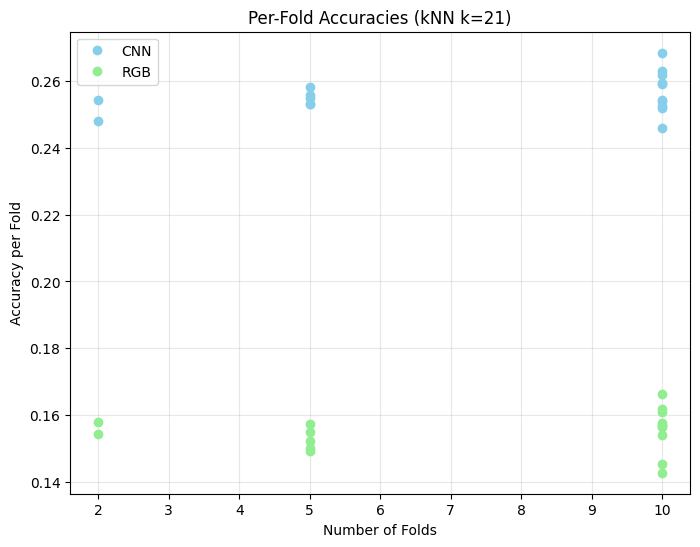

In [58]:
plt.figure(figsize=(8,6))

# CNN per fold
for i, folds in enumerate(kfold_list):
    plt.plot([folds]*len(cnn_accuracies[i]), cnn_accuracies[i], 'o', color='skyblue', label='CNN' if i==0 else "")

# RGB per fold
for i, folds in enumerate(kfold_list):
    plt.plot([folds]*len(rgb_accuracies[i]), rgb_accuracies[i], 'o', color='lightgreen', label='RGB' if i==0 else "")

plt.xlabel('Number of Folds')
plt.ylabel('Accuracy per Fold')
plt.title('Per-Fold Accuracies (kNN k=21)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


### [Optional] Exercise: further explore by: 
- implement other classifiers such as SVM or Random Forest, 
- extract other descriptors from the images such as objects or other local features,
- implement the evaluation metrics: recall, precision and f-score.